In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import cm
import matplotlib.colors as colors
from pathlib import Path

from models.mb_agent.mb_surnor import import_params_surnor
from fitting_behavior.off_policy.offpolicy_nor import offpolicy_nor
from fitting_behavior.mle.LL_nor import ll_nor

from fitting_behavior.off_policy.offpolicy_nac import offpolicy_nac
from fitting_behavior.mle.LL_nAC import ll_nac

from fitting_behavior.off_policy.offpolicy_hyb2 import offpolicy_hyb2
from fitting_behavior.mle.LL_hybrid import ll_hybrid
from fitting_behavior.mle.LL_hybrid2 import ll_hybrid2

import fitting_behavior.optimization.base_params_opt as bpo
import fitting_behavior.optimization.auxiliary_opt as auxo
import utils.saveload as sl
import utils.visualization as vis
import utils.hnov as hn
import utils.tree_env as tree

/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

# Novelty predictions along example path (Fig. 3D, right panel)

In [2]:
# Set based path to project directory
base_path = sl.get_rootpath()

path_fig = base_path / 'output' / 'off_policy_predictions'
sl.make_long_dir(path_fig)

# Construct toy example data
sequence = pd.DataFrame({'state':       np.array([0,1,2,4,8,16,32,64,32,65,32,16,33,16,8,4,2,5,2,1],dtype=int), 
                         'action':      np.array([1,2,2,2,2,2,2,0,3,0,0,3,0,0,0,0,3,0,0,3],dtype=int),
                         'next_state':  np.array([1,2,4,8,16,32,64,32,65,32,16,33,16,8,4,2,5,2,1,3],dtype=int)
                         })
# actions: 0 = backward, 1 = forward, 2 = left, 3 = right
mark_points = [1, # entry into maze
               6, # entry into new level-5 component
               9, # entry into new level-6 component
               12,
               17,
               20]
mark_labels = ['First entry into maze',
               'First visit of new C6 comp.',
               'First visit of new C5 comp.',
               'First visit of new C2 comp.',
               'First visit of new C1 comp.']


In [3]:
def plot_nov(rec_all,labels,cols,algname,plot_field,mark_points=[],figsize=(5,1.8)):
    f,ax = plt.subplots(1,1,figsize=figsize)
    for mp in mark_points:
        ax.axvline(x=mp,color='grey',ls='-',lw=1,alpha=1)
    for ii, rec in enumerate(rec_all):
        # ax.scatter(rec['time'],rec[plot_field],label=labels[ii],color=cols[ii])
        ax.plot(rec['time'][1:],rec[plot_field][1:],'-',color=cols[ii],label=labels[ii])
    ax.set_xticks(np.arange(1,rec['time'].max()+1))
    ax.set_xticklabels([f'{ii}' if ii%2==0 else '' for ii in np.arange(1,rec['time'].max()+1)])
    # ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Time steps in maze')
    ax.set_ylabel('Novelty signal')
    ax.legend(ncol=1,loc='lower right',bbox_to_anchor=(1.4,0),frameon=False,handlelength=0.8,handletextpad=0.3)
    # ax.set_title(f'Novelty signals of {algname} along test path')
    return f,ax

def plot_fam(rec_all,labels,cols,algname,plot_field):
    f,ax = plt.subplots(1,1,figsize=(5,5))
    for ii, rec in enumerate(rec_all):
        ax.scatter(rec['time'],rec[plot_field],label=labels[ii],color=cols[ii])
        ax.plot(rec['time'],rec[plot_field],'--',color=cols[ii])
    ax.axvline(x=np.where(rec['state']==64)[0],color='k',ls=':')
    ax.set_xlabel('Time steps in maze')
    ax.set_ylabel('Familiarity of next state')
    ax.legend()
    ax.set_title(f'Novelty signals of {algname} along test path')

def plot_qvals(q_all, labels, tr, sequence):
    # Plot Q-values of leaky vs. non-leaky along path
    f, ax = plt.subplots(len(q_all),1,figsize=(16,4*len(q_all)))
    v_all = []
    vmin_all = []
    vmax_all = []
    for ii, q in enumerate(q_all):
        q_ii = q_all[ii]
        v_ii = np.stack([np.nanmax(q_ii_kk, axis=1) for q_ii_kk in q_ii]) # shape: (time steps, states in maze)
        v_all.append(v_ii)
        vmin_all.append(np.nanmin(v_ii))
        vmax_all.append(np.nanmax(v_ii))
    for ii, v_ii in enumerate(v_all):
        aii = ax[ii].imshow(v_ii, vmin=np.min(vmin_all), vmax=np.max(vmax_all), aspect='auto', cmap='binary')
        ax[ii].set_title(f'Q-values: {labels[ii]}')
        ax[ii].set_xlabel('Node id')
        ax[ii].set_ylabel('Time step in maze')
        ax[ii].scatter(sequence.state, sequence.index, color='r', s=10)
        ax[ii].plot(sequence.state, sequence.index, color='r', ls='--')
        plt.colorbar(aii, ax=ax[ii], label='Q-value', orientation='vertical', shrink=1)
    
        len_levels = [len(tr.loc[tr.level==i]) for i in tr.level.unique()]
        for i in range(len(len_levels)):
            ax[ii].axvline(np.sum(len_levels[:i+1])-0.5, color='m', ls='-', lw=1)  # lines between levels
            
    return f, ax

/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

[0.008]


/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

[0.008]


/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

[0.008]


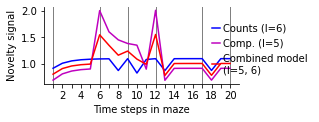

In [4]:
####### nor/nac/hyb model: off-policy (comp. with nor) ###################
alph_leak = 0.5 #[0, 0.1, 0.5]
update_type = ['leaky']

comp_norm   = True
maze_norm   = False
uniform_initial = True

join_levels = False # combine different distributions on novelty level

for jj, (ut) in enumerate(update_type):
    
    hlevels     = [[6], [5], [5,6]]
    notrace     = [[True], [True], [True, True]]
    eps_leak    = [[8e-3], [8e-3], [8e-3, 8e-3]]
    center      = False
    center_type = 'triangle'

    comp_algs   = ['hnor']*len(hlevels)
    labels      = ['Counts (l=6)', 'Comp. (l=5)', 'Combined model\n(l=5, 6)']
    cols        = ['b','m','r']
    
    rec_all = []
    q_all   = []
    for ii, cc in enumerate(comp_algs):
        if cc=='nor':
            # Load default parameters for nor model
            params = bpo.base_params_mbnortree_exp.copy()
            params_surnor = import_params_surnor(path = base_path / 'src' / 'models' / 'mb_agent')
            params.update(params_surnor)

            # Simulate leaky nor model (off-policy) + extract novelty signals
            ke = eps_leak[ii][0]
            params['alph_leak'] = alph_leak
            params['h']['alph_leak'] = alph_leak
            params['eps_leak'] = [ke]
            params['h']['eps_leak'] = [ke]
            print([ke])
            params['h']['update_type'] = ut
            rec_nor, q_nor = offpolicy_nor(params,sequence,rec_counts=True, rec_qvals=jj==0)
            if jj==0:
                q_all.append(q_nor)
            rec_all.append(rec_nor)

        elif cc=='hnor':
            # Load default parameters for nor model
            params = bpo.baseparams_h1mbnor(hlevels[ii],join_levels=join_levels,notrace=notrace[ii],center=center,center_type=center_type,update_type=None,comp_norm=comp_norm,maze_norm=maze_norm,uniform_initial=uniform_initial)
            params_surnor = import_params_surnor(path = base_path / 'src' / 'models' / 'mb_agent')
            params.update(params_surnor)

            # Simulate leaky nor model (off-policy) + extract novelty signals
            ke = eps_leak[ii][0]
            params['alph_leak'] = alph_leak
            params['h']['alph_leak'] = alph_leak
            params['eps_leak'] = [ke]
            params['h']['eps_leak'] = [ke]
            print([ke])
            params['h']['update_type'] = ut
            params['w'] = [1] if len(hlevels[ii])==1 else [0.5, 0.5]*len(hlevels[ii])
            rec_nor, q_nor = offpolicy_nor(params,sequence,rec_weights=False, rec_qvals=jj==0)
            if jj==0:
                q_all.append(q_nor)
            rec_all.append(rec_nor)

    # Plot novelty signals of leaky vs. non-leaky along path
    f,ax = plot_nov(rec_all,labels,cols,'nor',plot_field='nov_s_new',mark_points=mark_points)
    # ax.

    # f.suptitle(f'Leakiness: $\\alpha$={alph_leak}, $\\epsilon$={ke}')
    f.tight_layout()
    path_fig = base_path / 'output' / 'off_policy_predictions'
    sl.make_long_dir(path_fig)
    name_fig = f'comp-cnov-snov_trace-nocenter_{ut}' + ('' if ut=='var' else f'-{ke}')
    f.savefig(path_fig / f'{name_fig}.svg')

    # if jj==0:
    #     f2, ax2 = plot_qvals(q_all, labels, tr, sequence)
    #     f2.tight_layout()

rec_all1 = rec_all.copy()

# Path visualization (Fig. 3D, left panel)

/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

Both a random seed and fixed reward location provided. Environment is initialized with fixed reward location.
[0, 1, 2, 4, 8, 16, 32, 64, 32, 65, 32, 16, 33, 16, 8, 4, 2, 5, 2, 1, 3]


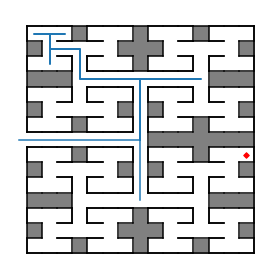

In [5]:
# Make binary tree
mytree = tree.make_rtree_env(6,1234)
xr, Pr, Rr, Tr = tree.tree_df2list(mytree)
_,_,coo = hn.assign_coor_eucl(mytree)

# Make kernel hierarchy
tr, mp, mp_matrix = hn.assign_av(mytree) 

# Plot basic maze 
fig,ax = plt.subplots(1,1,figsize=(4,4))
fig,ax,nb,pb = hn.plot_maze3(mytree,fig=fig,ax=ax,plot_state=False) 

# Plot path
mytree1, mp, mp_mat = hn.assign_coor_eucl(mytree)
states_path = [ii for ii in sequence['state'].values] + [sequence['next_state'].values[-1]]
print(states_path)
x_path = [mytree1.loc[mytree1.state==ii,'x_eucl'].values for ii in states_path]
y_path = [mytree1.loc[mytree1.state==ii,'y_eucl'].values for ii in states_path]

r = ax.plot(x_path,y_path,'-')

/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

Both a random seed and fixed reward location provided. Environment is initialized with fixed reward location.
0.0625


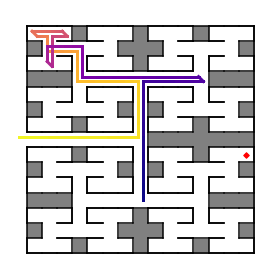

In [6]:
# Make binary tree
mytree = tree.make_rtree_env(6,1234)
xr, Pr, Rr, Tr = tree.tree_df2list(mytree)
_,_,coo = hn.assign_coor_eucl(mytree)

# Make kernel hierarchy
tr, mp, mp_matrix = hn.assign_av(mytree) 

# Get plot coordinates of example path
mytree1, mp, mp_mat = hn.assign_coor_eucl(mytree)
states_path = [ii for ii in sequence['state'].values] + [sequence['next_state'].values[-1]]
x_path = [mytree1.loc[mytree1.state==ii,'x_eucl'].values[0] for ii in states_path]
y_path = [mytree1.loc[mytree1.state==ii,'y_eucl'].values[0] for ii in states_path]

xdiff = np.abs(np.diff(x_path))
ydiff = np.abs(np.diff(y_path))
prec_plot = np.min(list(xdiff[xdiff!=0])+list(ydiff[ydiff!=0]))/2
print(prec_plot)

# Put intermediate points for color gradient
x_path_plot = []; y_path_plot = []
prec_plot = 0.05
prec_round = 2
offsets = [0.02] + [-0.02]*6 + [0.02]*2 + [-0.02] + [0.02]*2 + [-0.02] + [0.02]*4 + [-0.02] + [0.02]*2
# np.linspace(-0.04,0.04,num=len(x_path))
offset_pre = 0
for ii, (xx1,xx2,yy1,yy2) in enumerate(zip(x_path[:-1],x_path[1:],y_path[:-1],y_path[1:])):
    offset_curr = offsets[ii]
    if ii<len(x_path)-2:
        offset_next = offsets[ii+1]
    else:
        offset_next = 0
    # print(ii)
    if xx1!=xx2:
        # print(f'x1: {xx1}')
        # print(f'x2: {xx2}')
        xadd = list(np.linspace(xx1+offset_pre,xx2+offset_next,num=5))
        # xadd.append(xx2)
        # prec_plot_ii = np.sign(xx2-xx1)*prec_plot
        # print(f'prec_plot_ii: {prec_plot_ii}')
        # xadd = list(np.round(np.arange(xx1,xx2,prec_plot_ii),prec_round))
        # if xadd[-1]!=xx2: 
        #     xadd.append(xx2)
        yadd = [yy1+offset_curr]*len(xadd)
    elif yy1!=yy2:
        # print(f'y1: {yy1}')
        # print(f'y2: {yy2}')
        yadd = list(np.linspace(yy1+offset_pre,yy2+offset_next,num=5))
        # yadd.append(yy2)
        # prec_plot_ii = np.sign(yy2-yy1)*prec_plot
        # print(f'prec_plot_ii: {prec_plot_ii}')
        # yadd = list(np.round(np.arange(yy1,yy2,prec_plot),prec_round))
        # print(f'yadd: {yadd}')
        # if yadd[-1]!=yy2: yadd.append(yy2)
        xadd = [xx1+offset_curr]*len(yadd)
    x_path_plot.extend(xadd)
    y_path_plot.extend(yadd)

    offset_pre = offset_curr

MAP = 'plasma'
NPOINTS = len(x_path_plot)

fig,ax = plt.subplots(1,1,figsize=(4,4))
fig,ax,nb,pb = hn.plot_maze3(mytree,fig=fig,ax=ax,plot_state=False) 
cm = plt.get_cmap(MAP)
# ax.scatter(x_path_plot[0],y_path_plot[0],c=cm.to_rgba(0))
# ax.scatter(x_path_plot[-1],y_path_plot[-1],c=cm.to_rgba(1))
ax.set_prop_cycle(color=[cm(1.0*i/(NPOINTS-1)) for i in range(NPOINTS-1)][::-1])
for i in range(NPOINTS-1):
    ax.plot(x_path_plot[i:i+2],y_path_plot[i:i+2],lw=3)

fig.tight_layout()
name_fig = f'comp-cnov-snov_samplepath'
fig.savefig(path_fig / f'{name_fig}.svg')